# Disaster Tweets Prediction
In this notebook, we will be predicting the disaster tweets based on the given dataset. You can find the competition and the dataset [here](https://www.kaggle.com/competitions/nlp-getting-started).

<div align="center">
<img src="https://www.kaggle.com/competitions/17777/images/header" />
</div>

## 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import re
import nltk
import neattext as ntx
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings

### Configurations

In [2]:
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('darkgrid')

## 2. Loading Data

In [3]:
df = pd.read_csv('train.csv', index_col='id')

In [4]:
df.head()

,keyword,location,text,target
id,,,,
1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [5]:
df.shape

(7613, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7613 entries, 1 to 10873
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   keyword   7552 non-null   object
 1   location  5080 non-null   object
 2   text      7613 non-null   object
 3   target    7613 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 297.4+ KB


In [7]:
df.isnull().sum()

keyword       61
location    2533
text           0
target         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(52)

In [9]:
df.drop_duplicates(inplace=True)

## 3. Exploratory Data Analysis

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
target,7561.0,0.428382,0.494877,0.0,0.0,0.0,1.0,1.0


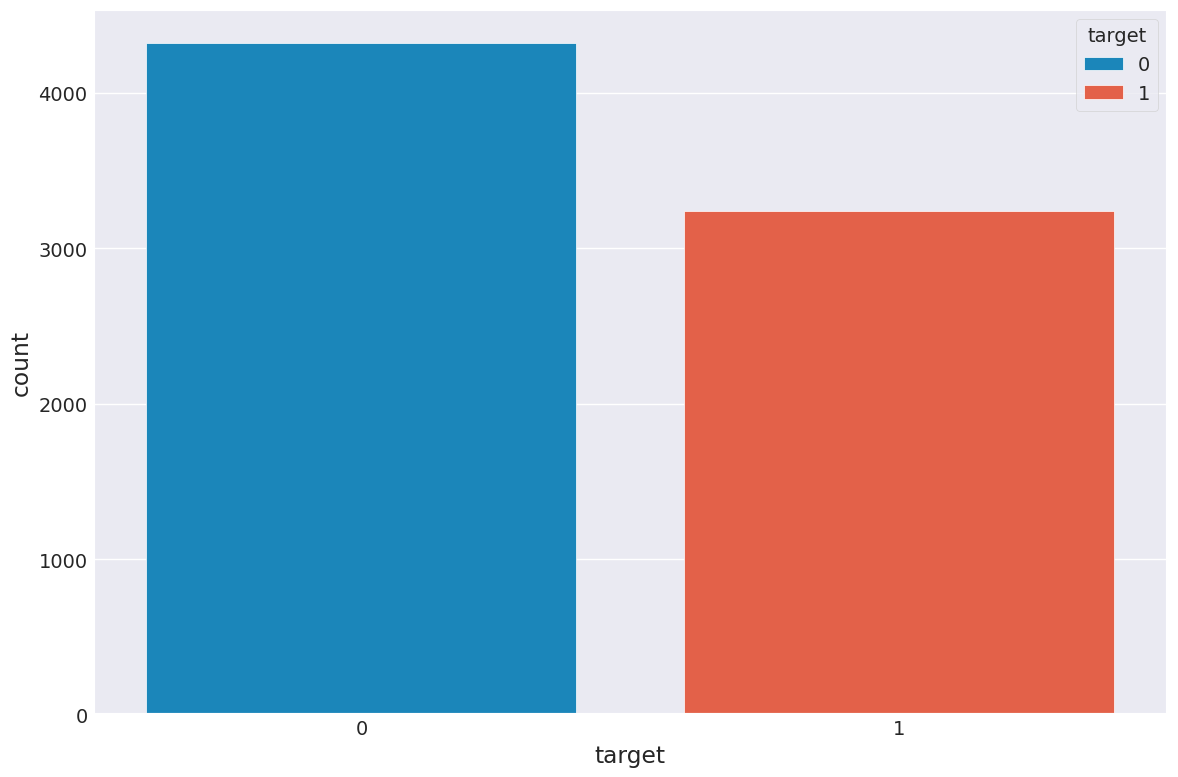

In [11]:
sns.countplot(df, x='target', hue='target')
plt.tight_layout()

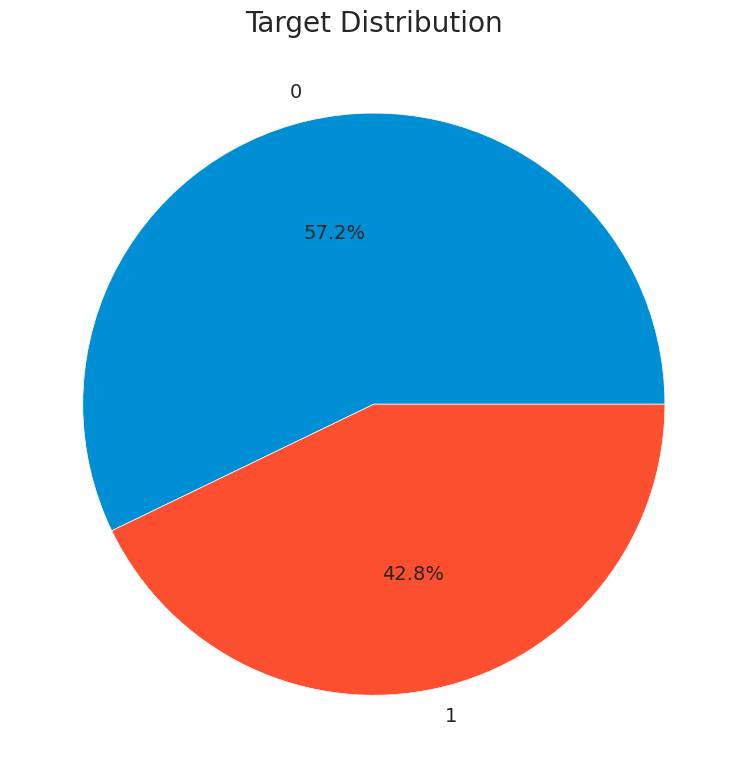

In [12]:
df['target'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Target Distribution')
plt.ylabel('')
plt.tight_layout()

## 4. Natural Language Processing

In [13]:
df['hashtags'] = df['text'].apply(lambda x: ', '.join(ntx.extract_hashtags(x.lower())))
df.hashtags.head()

id
1            #earthquake
4                       
5                       
6             #wildfires
7    #alaska, #wildfires
Name: hashtags, dtype: object

In [14]:
stemmer = nltk.SnowballStemmer('english')

def process_text(text):
    text = text.lower()
    text = ntx.remove_emails(text)
    text = ntx.remove_dates(text)
    text = ntx.remove_hashtags(text)
    text = ntx.remove_phone_numbers(text)
    text = ntx.remove_urls(text)
    text = ntx.remove_userhandles(text)
    text = ntx.remove_custom_pattern(text, r'&amp;')
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = ntx.remove_numbers(text)
    text = ntx.remove_stopwords(text)
    text = ntx.remove_multiple_spaces(text)
    text = ' '.join([stemmer.stem(word) for word in text.split()])
    return text

In [15]:
df['text_clean'] = df['text'].apply(process_text)

In [16]:
texts = ' '.join(df['text_clean'])
texts[:100]

'deed reason allah forgiv forest fire near la rong sask canada resid ask shelter place notifi offic e'

In [17]:
def wc(text):
    wordcloud = WordCloud(
        width=800, height=400, 
        background_color='white',
    ).generate(text)
    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

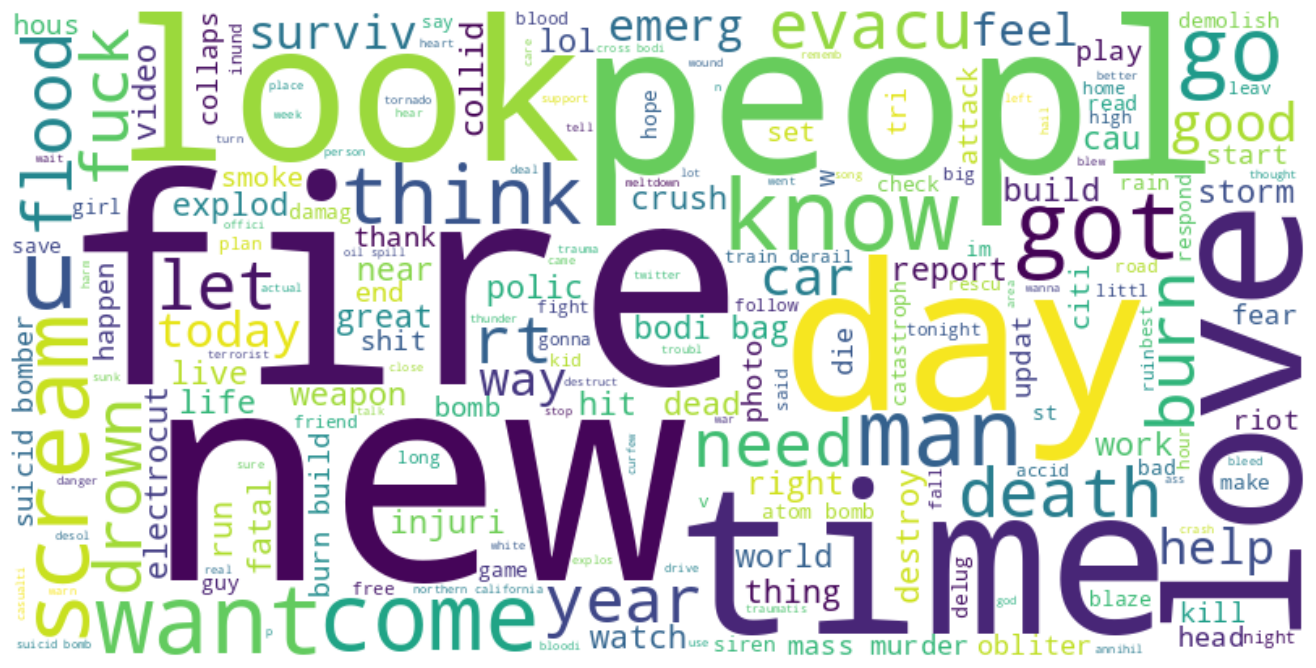

In [18]:
wc(texts)

In [19]:
disaster_texts = ' '.join(df[df.target == 1].text_clean)
non_disaster_texts = ' '.join(df[df.target == 0].text_clean)

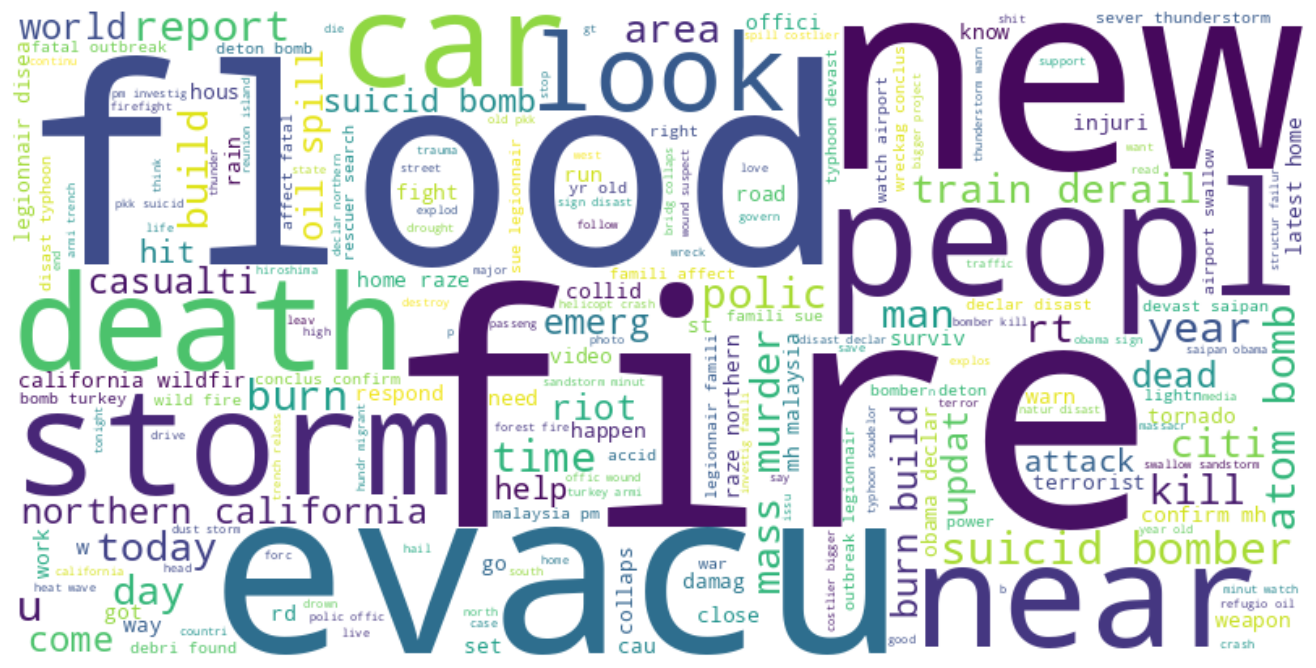

In [20]:
wc(disaster_texts)

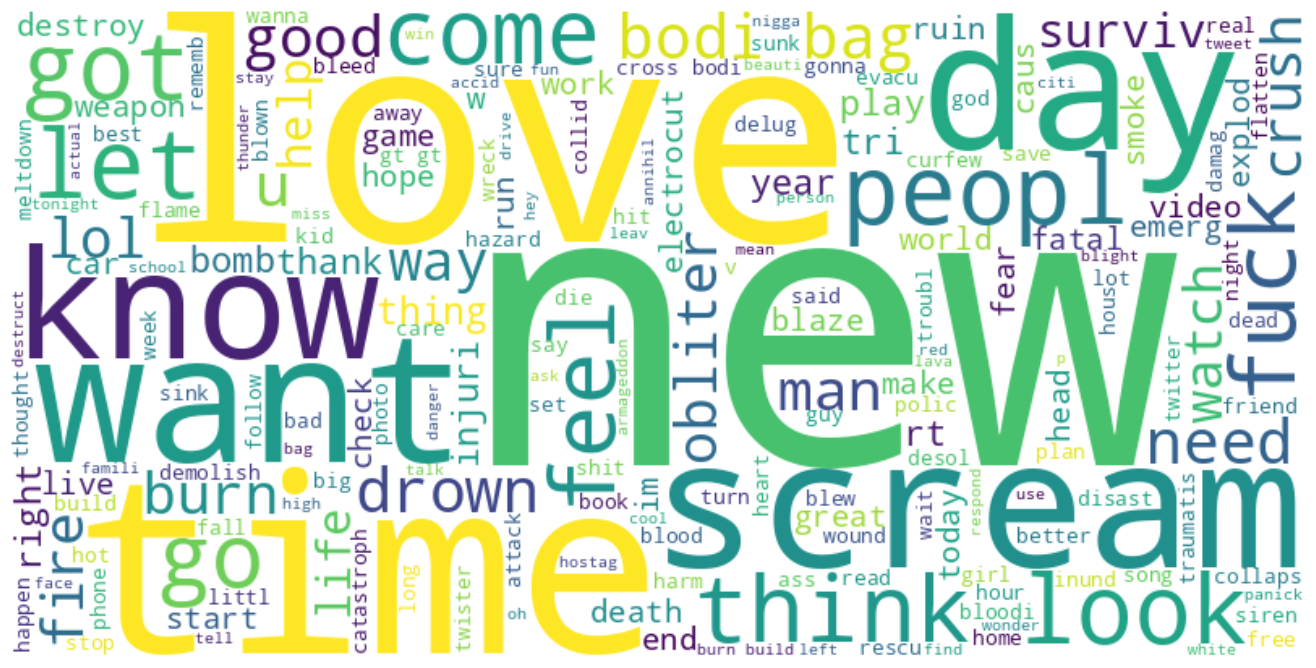

In [21]:
wc(non_disaster_texts)

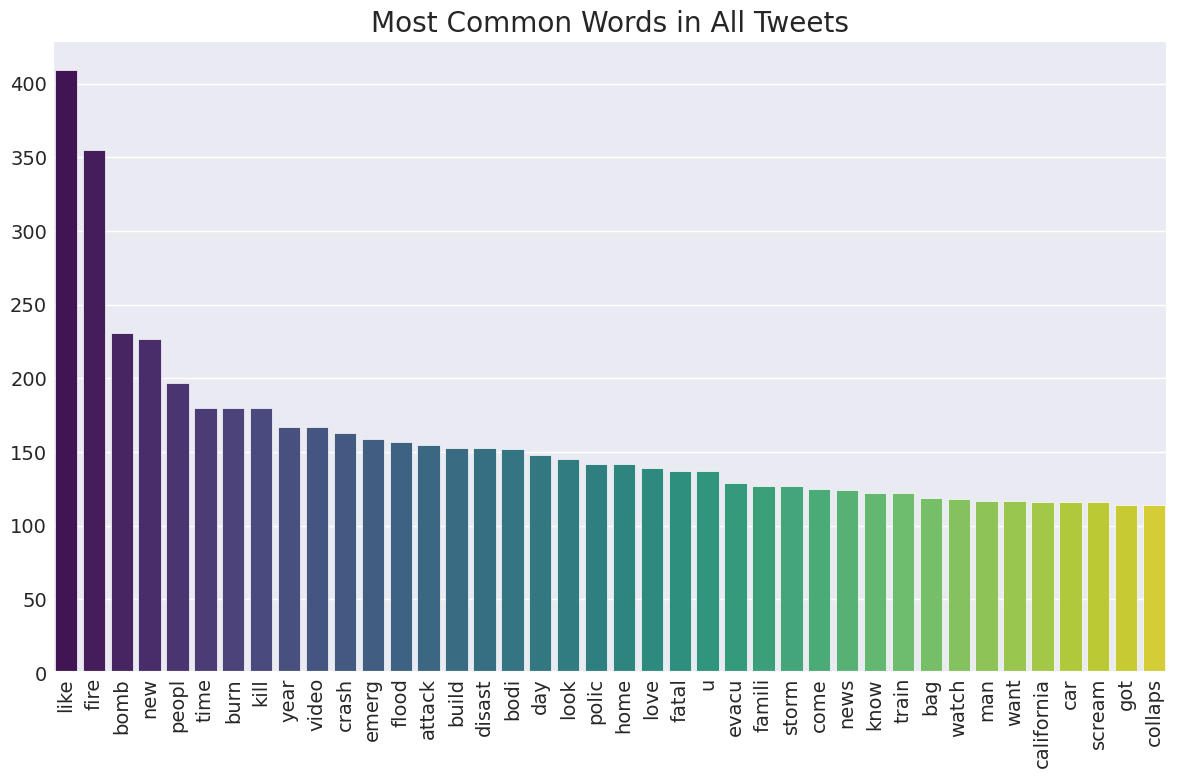

In [22]:
# most common words
mcw = dict(Counter(texts.split()).most_common(40))

sns.barplot(
    x=mcw.keys(),
    y=mcw.values(),
    hue=mcw.keys(),
    palette='viridis'
)
plt.xticks(rotation=90)
plt.title('Most Common Words in All Tweets')
plt.tight_layout()

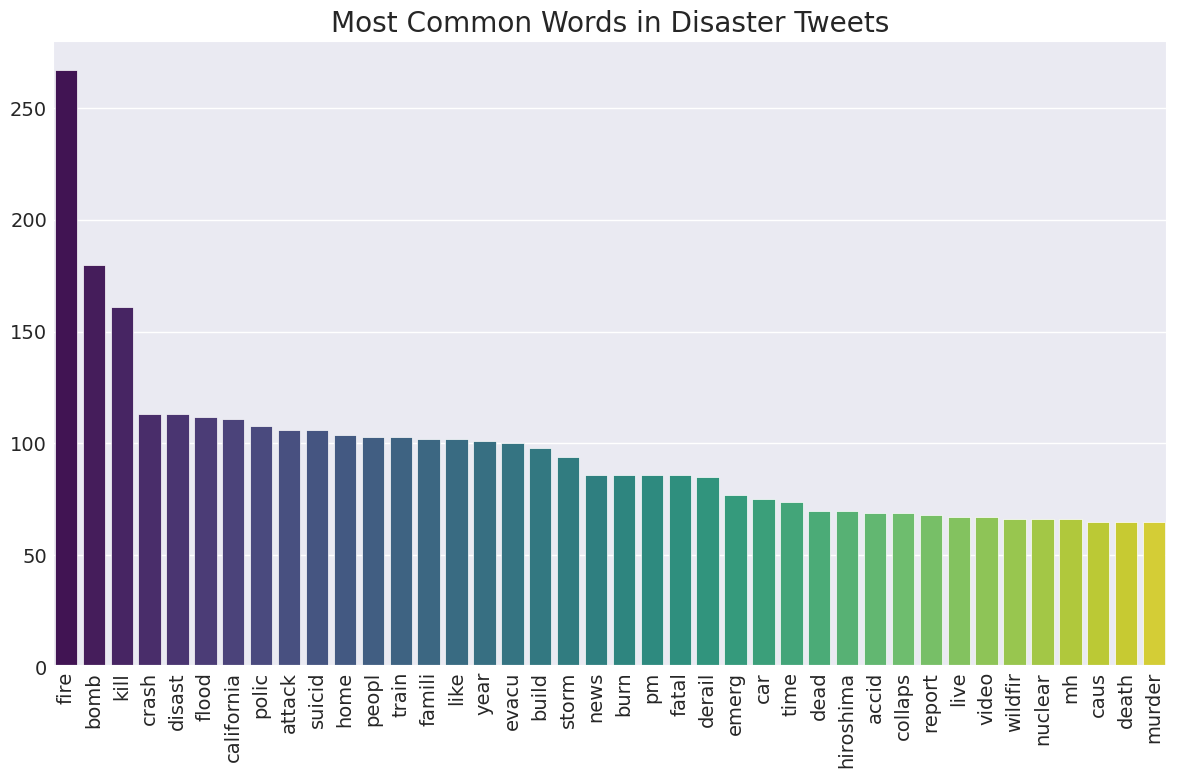

In [23]:
# most common words in disaster tweets
mcwd = dict(Counter(disaster_texts.split()).most_common(40))

sns.barplot(
    x=mcwd.keys(),
    y=mcwd.values(),
    hue=mcwd.keys(),
    palette='viridis'
)
plt.xticks(rotation=90)
plt.title('Most Common Words in Disaster Tweets')
plt.tight_layout()

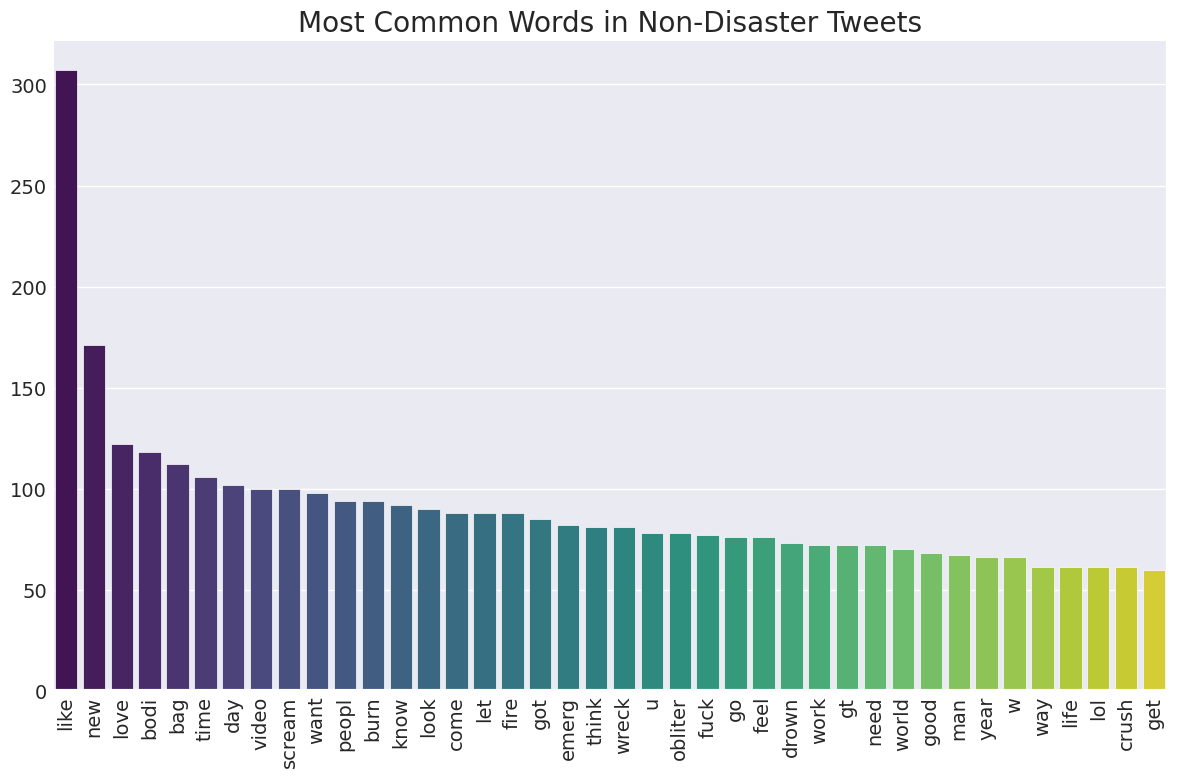

In [24]:
# most common words in non-disaster tweets
mcwn = dict(Counter(non_disaster_texts.split()).most_common(40))

sns.barplot(
    x=mcwn.keys(),
    y=mcwn.values(),
    hue=mcwn.keys(),
    palette='viridis'
)
plt.xticks(rotation=90)
plt.title('Most Common Words in Non-Disaster Tweets')
plt.tight_layout()

In [25]:
df.head()

,keyword,location,text,target,hashtags,text_clean
id,,,,,,
1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,#earthquake,deed reason allah forgiv
4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,,forest fire near la rong sask canada
5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,,resid ask shelter place notifi offic evacu she...
6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,#wildfires,peopl receiv evacu order california
7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,"#alaska, #wildfires",got sent photo rubi smoke pour school


In [26]:
df.text_clean + ' ' + df.hashtags

id
1                     deed reason allah forgiv #earthquake
4                    forest fire near la rong sask canada 
5        resid ask shelter place notifi offic evacu she...
6           peopl receiv evacu order california #wildfires
7        got sent photo rubi smoke pour school #alaska,...
                               ...                        
10869          giant crane hold bridg collaps nearbi home 
10870    control wild fire california northern state tr...
10871                               utc km volcano hawaii 
10872    polic investig e bike collid car littl portug ...
10873    latest home raze northern california wildfir a...
Length: 7561, dtype: object

## 5. Data Preprocessing

In [27]:
x = np.array(df.text_clean + ' ' + df.hashtags)
y = np.array(df.target)

In [28]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2))
x_vec = vectorizer.fit_transform(x)

In [29]:
x_vec.shape

(7561, 50263)

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x_vec, y, test_size=0.2, random_state=42)

In [31]:
x_train.shape

(6048, 50263)

## 6. Model Training

In [32]:
models = {
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB(),
    'LogisticRegression': LogisticRegression(),
    'ExtraTreesClassifier': ExtraTreesClassifier(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier(n_neighbors=5),
    'XGBClassifier': xgb.XGBClassifier(),
    'LightGBMClassifier': lgb.LGBMClassifier(verbose=-1)
}

def evaluate(x_train, y_train, x_test, y_test):
    results = []

    for i, (model_name, model) in enumerate(tqdm(models.items())):
        if 'random_state' in model.get_params():
            model.set_params(random_state=42)

        print(f'Training {model_name}...')
        y_pred = model.fit(x_train, y_train).predict(x_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='macro')
        recall = recall_score(y_test, y_pred, average='macro')
        f1 = f1_score(y_test, y_pred, average='macro')

        plt.subplot(2, 5, i+1)
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(model_name, fontsize=12)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()

        results.append({
            'Model': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1
        })
        
    plt.suptitle('Confusion Matrices of All Models')
    plt.tight_layout()
    
    report = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
    report.reset_index(drop=True, inplace=True)
    return report

  0%|          | 0/10 [00:00<?, ?it/s]

Training MultinomialNB...
Training BernoulliNB...
Training LogisticRegression...
Training ExtraTreesClassifier...
Training DecisionTreeClassifier...
Training RandomForestClassifier...
Training GradientBoostingClassifier...
Training KNeighborsClassifier...
Training XGBClassifier...
Training LightGBMClassifier...


,Model,Accuracy,Precision,Recall,F1 Score
0,MultinomialNB,0.795109,0.812058,0.769241,0.777196
1,RandomForestClassifier,0.780568,0.798299,0.752710,0.759993
2,LogisticRegression,0.779907,0.804200,0.749438,0.756841
3,BernoulliNB,0.778586,0.817922,0.743343,0.750454
4,LightGBMClassifier,0.778586,0.774554,0.765893,0.769013
5,XGBClassifier,0.777264,0.782158,0.755739,0.761757
6,ExtraTreesClassifier,0.776603,0.786452,0.752015,0.758617
7,KNeighborsClassifier,0.741573,0.769555,0.704832,0.708152
8,GradientBoostingClassifier,0.740912,0.780598,0.700657,0.702607
9,DecisionTreeClassifier,0.730337,0.723003,0.724510,0.723671


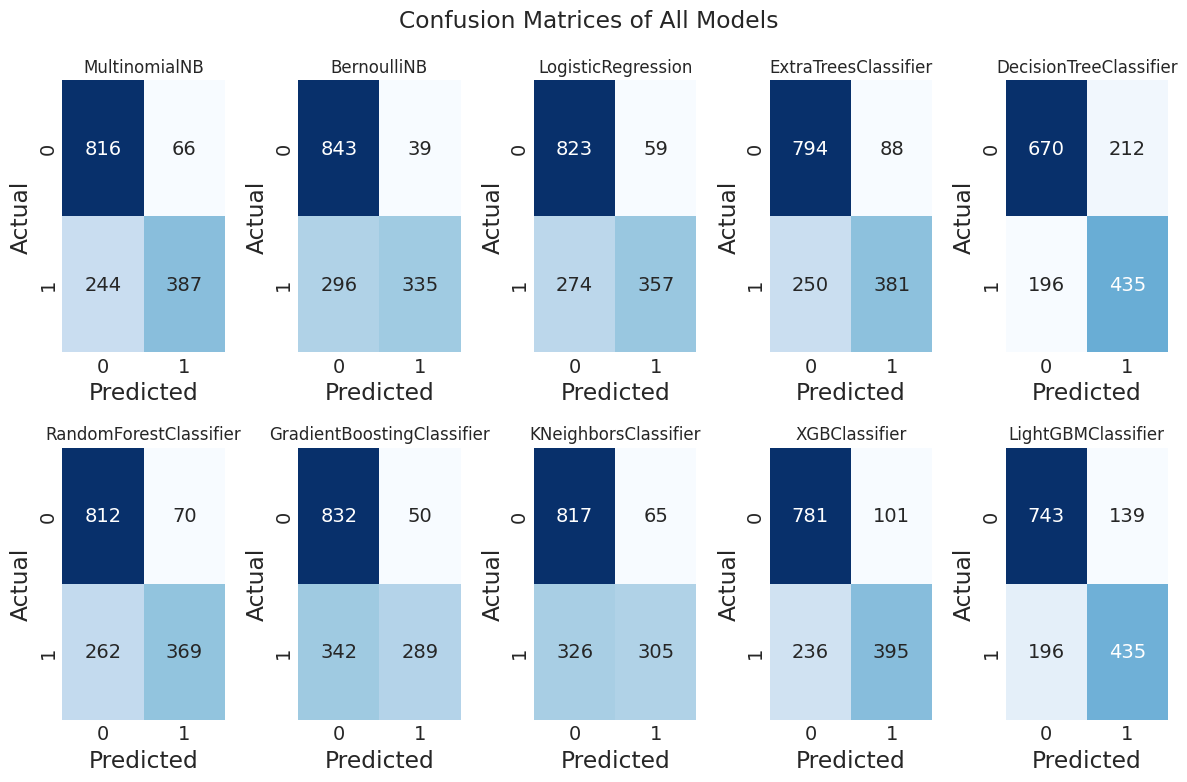

In [33]:
evaluate(x_train, y_train, x_test, y_test)

### Deep Learning

In [39]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GlobalAveragePooling1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

In [40]:
# Tokenization & Padding
vocab_size = 50000
max_len = 200
oov_token = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(df['text_clean'])
sequences = tokenizer.texts_to_sequences(df['text_clean'])
padded = pad_sequences(sequences, maxlen=max_len, padding='post')

In [41]:
x_train_pad, x_test_pad, y_train_pad, y_test_pad = train_test_split(padded, df.target, test_size=0.2, random_state=42)

In [42]:
model = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    Bidirectional(LSTM(256, return_sequences=True)),
    GlobalAveragePooling1D(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

In [43]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [44]:
history = model.fit(
    x_train_pad, y_train_pad,
    epochs=50,
    batch_size=256,
    validation_data=(x_test_pad, y_test_pad),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


2025-10-23 10:07:17.908352: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301


24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.5671 - loss: 0.6863 - val_accuracy: 0.5829 - val_loss: 0.6798
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 279ms/step - accuracy: 0.5689 - loss: 0.6855 - val_accuracy: 0.5829 - val_loss: 0.6796
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.5638 - loss: 0.6874 - val_accuracy: 0.5829 - val_loss: 0.6794
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.5686 - loss: 0.6858 - val_accuracy: 0.5829 - val_loss: 0.6809
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.5688 - loss: 0.6847 - val_accuracy: 0.5829 - val_loss: 0.6786
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.5691 - loss: 0.6829 - val_accuracy: 0.6504 - val_loss: 0.6407
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.5413 - loss: 0.7408 - val_accuracy: 0.5829 - val_loss: 0.6788
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.5625 - loss: 0.6857 - val_accuracy: 0.5829 - val

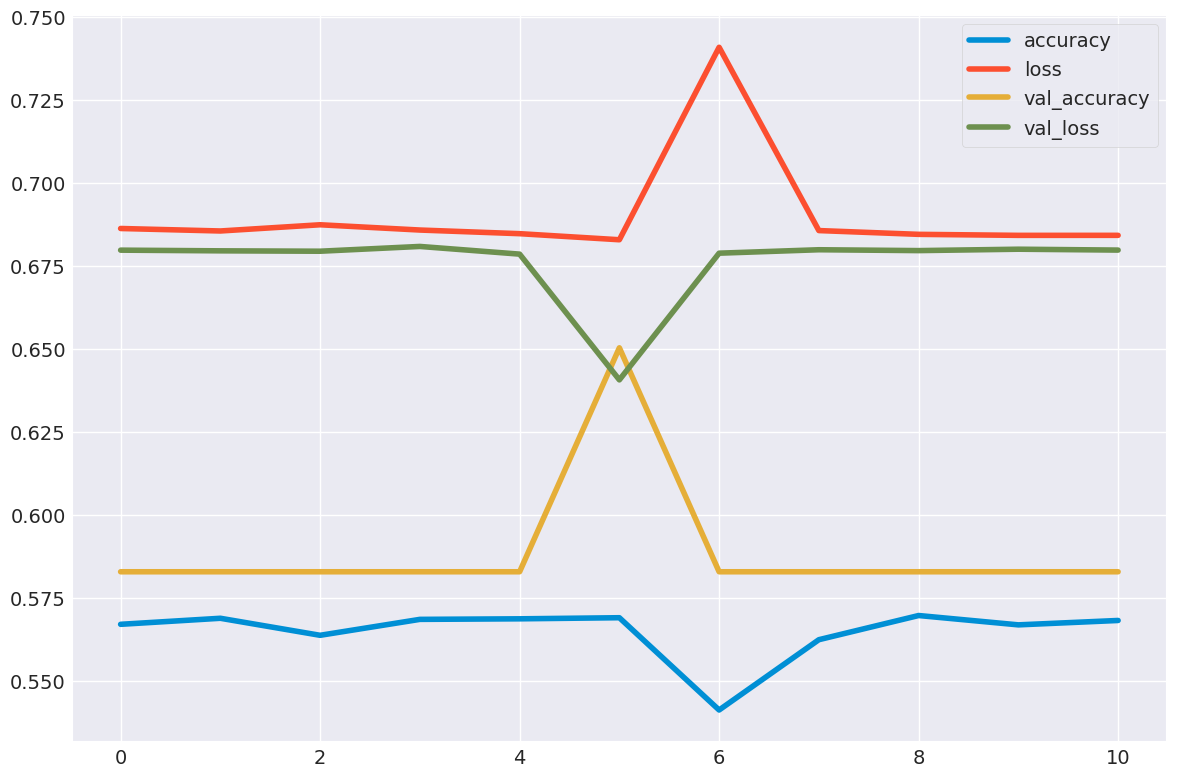

In [45]:
pd.DataFrame(history.history).plot()
plt.tight_layout()

In [47]:
val_loss, val_acc = model.evaluate(x_test_pad, y_test_pad)
print(f'Validation Loss     : {val_loss:.4f}')
print(f'Validation Accuracy : {val_acc:.4f}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6504 - loss: 0.6407
Validation Loss     : 0.6407
Validation Accuracy : 0.6504


In [48]:
train_loss, train_acc = model.evaluate(x_train_pad, y_train_pad)
print(f'Training Loss       : {train_loss:.4f}')
print(f'Training Accuracy   : {train_acc:.4f}')

189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.6546 - loss: 0.6331
Training Loss       : 0.6331
Training Accuracy   : 0.6546


## 7. Build a Pipeline, Save the Model, Make Submission

In [49]:
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 3))),
    ('model', MultinomialNB())
])
pipeline.fit(x, y)

,steps,"[('vectorizer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [50]:
pipeline.score(x, y)

0.9545033725697659

In [51]:
y_pred = pipeline.predict(x)

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      4322
           1       0.98      0.91      0.95      3239

    accuracy                           0.95      7561
   macro avg       0.96      0.95      0.95      7561
weighted avg       0.96      0.95      0.95      7561



In [52]:
accuracy_score(y, y_pred)

0.9545033725697659

In [53]:
joblib.dump(pipeline, 'disaster_tweets_pipeline.pkl')

['disaster_tweets_pipeline.pkl']

In [54]:
test_df = pd.read_csv('test.csv', index_col='id')

test_df['hashtags'] = test_df['text'].apply(lambda x: ', '.join(ntx.extract_hashtags(x.lower())))
test_df['text_clean'] = test_df['text'].apply(process_text)
x_sub = np.array(test_df['text_clean'] + ' ' + test_df['hashtags'])

predictions = pipeline.predict(x_sub)

submission = pd.DataFrame({
    'id': test_df.index,
    'target': predictions
})
submission.head()

,id,target
0,0,1
1,2,1
2,3,1
3,9,0
4,11,1


In [55]:
submission.to_csv('submission.csv', index=False)

## 8. Conclusion
We built a machine learning pipeline to predict the disaster tweets. We used the `MultinomialNB` model as the best model. We saved the pipeline for future use and used it to generate predictions for the test set.